# Which bookmaker is sharpest?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Propertyscout001/puntersedge-datasets/blob/main/notebooks/01_which_bookmaker_is_sharpest.ipynb)

Two different questions hide inside "which bookmaker is best":

1. **Who pays the most?** How often each bookmaker has the best price, how far its prices sit from the typical price, and how much margin it builds into a race.
2. **Who is sharpest?** Whose prices best predict which runner wins. A sharp bookmaker's prices are accurate; a generous one's are long. They are not the same thing.

This notebook answers both from the free monthly [closing-line dataset](https://puntersedge.online/datasets), using the same method as the daily [PuntersEdge bookmaker report](https://puntersedge.online/bookmaker-report). The report compares every served bookmaker; the dataset carries five of them, so here the comparison is among those five. Runs top to bottom in Colab with nothing to install.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RELEASE = "2026-09"
URL = ("https://puntersedge.online/datasets/au-racing-closing-lines/"
       f"{RELEASE}/au-racing-closing-lines-{RELEASE}.parquet")

# Reads the release straight from puntersedge.online (about 3 MB).
# Set PUNTERSEDGE_DATASET_FILE to the path of a downloaded copy to read that instead.
df = pd.read_parquet(os.environ.get("PUNTERSEDGE_DATASET_FILE", URL))

NAMES = {"tab": "TAB", "ladbrokes_au": "Ladbrokes", "pointsbetau": "PointsBet",
         "betright": "BetRight", "tabtouch": "TABtouch"}
print(f"{len(df):,} rows, {df.race_id.nunique():,} races, "
      f"{df.meeting_date_aet.min()} to {df.meeting_date_aet.max()}")
print("Bookmakers:", ", ".join(NAMES.get(b, b) for b in sorted(df.bookmaker_key.unique())))

233,872 rows, 6,274 races, 2026-09-01 to 2026-09-30
Bookmakers: BetRight, Ladbrokes, PointsBet, TAB, TABtouch


In [2]:
GREEN, AMBER, GREY, INK = "#1B7A4B", "#E3A008", "#8A948C", "#131C16"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#B8C1B6",
    "axes.grid": True, "grid.color": "#E6EAE3", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": INK, "xtick.color": "#5C6961", "ytick.color": "#5C6961",
    "text.parse_math": False,                 # "$3.00 to $6.99" is a price range, not maths
})

## 1. Who has the best price most often?

Every row is one runner at one bookmaker, with the bookmaker's last win price before the jump (`close_win_price`). For each runner we find the highest closing price across the bookmakers that priced it. A bookmaker scores when its price equals that best price; equal-best counts for everyone at that price, so the shares do not add to 100%.

Bookmakers price favourites and long shots differently, so we also split runners by their median closing price.

In [3]:
BANDS = [(1, 3, "Under $3.00"), (3, 7, "$3.00 to $6.99"), (7, 15, "$7.00 to $14.99"), (15, np.inf, "$15.00 and over")]

close_all = df[df.close_win_price > 1]                         # every closing price
close = close_all.copy()
g = close.groupby(["race_id", "runner_key"])
close["n_books"] = g.bookmaker_key.transform("nunique")
close = close[close.n_books >= 3].copy()                       # three prices before "best" means anything
g = close.groupby(["race_id", "runner_key"])
close["best"] = g.close_win_price.transform("max")
close["median"] = g.close_win_price.transform("median")
close["is_best"] = close.close_win_price >= close.best - 1e-9
close["band"] = pd.cut(close["median"], [b[0] for b in BANDS] + [np.inf], right=False,
                       labels=[b[2] for b in BANDS])

best = (close.groupby(["bookmaker_key", "band"], observed=True).is_best.mean().unstack() * 100)
best.insert(0, "All prices", close.groupby("bookmaker_key").is_best.mean() * 100)
best = best.rename(index=NAMES).sort_values("All prices", ascending=False).round(1)
print(f"{close.drop_duplicates(['race_id', 'runner_key']).shape[0]:,} runners with three or more closing prices")
best

48,519 runners with three or more closing prices


band,All prices,Under $3.00,$3.00 to $6.99,$7.00 to $14.99,$15.00 and over
bookmaker_key,,,,,
PointsBet,49.9,16.3,46.9,61.2,55.8
BetRight,44.7,49.3,44.3,39.4,46.8
TAB,39.6,36.9,35.8,42.5,41.2
TABtouch,28.3,32.7,37.7,31.8,18.5
Ladbrokes,19.3,46.0,23.3,14.2,11.6


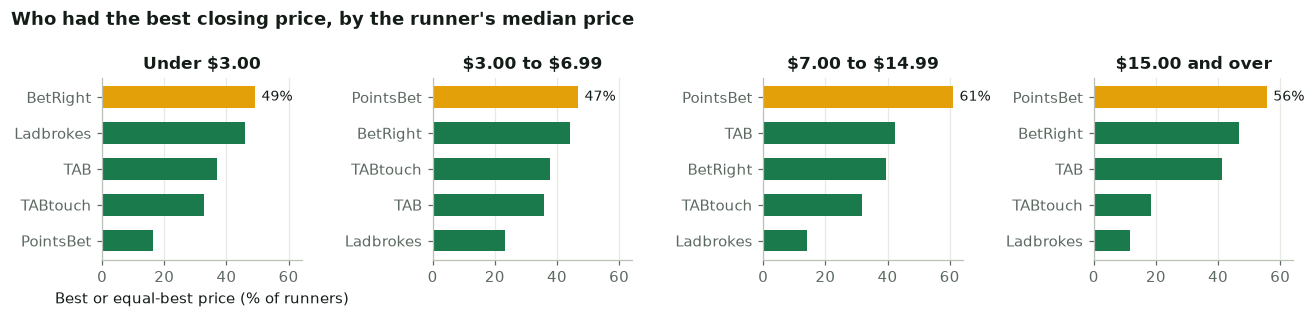

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2.9), sharex=True)
for ax, (_, _, label) in zip(axes, BANDS):
    col = best[label].sort_values()
    colors = [AMBER if v == col.max() else GREEN for v in col]
    ax.barh(col.index, col.values, color=colors, height=0.6)
    ax.set_title(label)
    ax.grid(axis="y", visible=False)
    top = col.idxmax()
    ax.annotate(f"{col.max():.0f}%", (col.max(), list(col.index).index(top)),
                xytext=(4, 0), textcoords="offset points", va="center", fontsize=9, color=INK)
axes[0].set_xlabel("Best or equal-best price (% of runners)")
fig.suptitle("Who had the best closing price, by the runner's median price", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
plt.show()

In [5]:
leaders = {label: best[label].idxmax() for _, _, label in BANDS}
for label, book in leaders.items():
    print(f"{label:>16}: {book} ({best.loc[book, label]}%)")

     Under $3.00: BetRight (49.3%)
  $3.00 to $6.99: PointsBet (46.9%)
 $7.00 to $14.99: PointsBet (61.2%)
 $15.00 and over: PointsBet (55.8%)


The leader changes with the price. That is the practical answer to "which bookmaker has the best odds": it depends on what you back.

## 2. How far from the typical price?

Best-price share says how often a bookmaker wins; it does not say by how much. Here each closing price is divided by the median closing price for the same runner, minus one. +2% means the bookmaker's price was 2% longer than the typical price.

In [6]:
close["rel"] = close.close_win_price / close["median"] - 1
rel = close.groupby(["bookmaker_key", "band"], observed=True).rel.mean().unstack() * 100
rel.insert(0, "All prices", close.groupby("bookmaker_key").rel.mean() * 100)
rel.rename(index=NAMES).sort_values("All prices", ascending=False).round(2)

band,All prices,Under $3.00,$3.00 to $6.99,$7.00 to $14.99,$15.00 and over
bookmaker_key,,,,,
PointsBet,3.51,-1.58,1.18,3.46,6.80
BetRight,1.66,0.57,0.40,-0.29,4.07
TAB,0.40,-0.35,-0.51,0.41,1.28
TABtouch,-0.91,0.15,0.35,0.02,-2.67
Ladbrokes,-2.77,0.54,-1.44,-3.44,-4.25


## 3. Market percentage

The sum of `1 / price` over a race's runners is the bookmaker's market percentage: 100% would be a market with no margin. It is only meaningful when the bookmaker priced the whole field, so races where it missed a runner are left out.

In [7]:
per_book = close_all.groupby(["race_id", "bookmaker_key"]).runner_key.transform("nunique")
field = per_book.groupby(close_all.race_id).transform("max")
full = close_all[(per_book == field) & (field >= 4)]
book_pct = (full.assign(inv=1 / full.close_win_price)
                .groupby(["race_id", "bookmaker_key"])
                .agg(category=("category", "first"), pct=("inv", "sum")))
mkt = book_pct.groupby(["bookmaker_key", "category"]).pct.median().unstack() * 100
mkt.insert(0, "All codes", book_pct.groupby("bookmaker_key").pct.median() * 100)
mkt.rename(index=NAMES).sort_values("All codes").round(1)

category,All codes,greyhound,harness,horse
bookmaker_key,,,,
BetRight,122.7,123.1,123.7,119.5
PointsBet,122.9,122.9,124.9,119.4
TABtouch,123.2,123.2,125.2,120.2
TAB,123.4,123.3,126.1,121.7
Ladbrokes,125.8,126.0,126.8,120.9


## 4. Who is sharpest?

Sharpness is about accuracy, not generosity. For each resulted race with one winner where a bookmaker priced the full field:

1. Remove the bookmaker's margin with the **power method**: find the exponent $k$ for which $\sum_i (1/\text{price}_i)^k = 1$, then each runner's probability is $(1/\text{price}_i)^k$. It takes more margin out of long shots than proportional scaling does, which matches how bookmakers build their markets.
2. Take the probability the bookmaker gave the **winner** and compare it with the average bookmaker in the same race, as a log score. Comparing within a race cancels out how predictable that race was.
3. Average across races. A positive figure means the bookmaker's prices gave winners more probability than the field did.

Five bookmakers are compared at once, so a difference counts only if its 95% interval clears zero after a Bonferroni correction. It is measured on the prices 60 minutes before the jump (series that began at the start of the archive's capture window) and on closing prices.

In [8]:
from statistics import NormalDist


def power_probabilities(prices, groups):
    """Margin-free probabilities by the power method, solved for every group at once."""
    p = 1.0 / np.asarray(prices, dtype=float)
    g = np.asarray(groups)
    n = g.max() + 1
    lo, hi = np.full(n, 0.05), np.full(n, 20.0)
    for _ in range(80):                                     # bisection on k, per group
        k = (lo + hi) / 2
        over = np.bincount(g, weights=p ** k[g], minlength=n) > 1
        lo, hi = np.where(over, k, lo), np.where(over, hi, k)
    q = p ** ((lo + hi) / 2)[g]
    return q / np.bincount(g, weights=q, minlength=n)[g]


# Races with a final result and exactly one winner (dead heats are left out).
winners = df[df.finish_position.eq(1)].groupby("race_id").runner_key.nunique()
single = winners[winners.eq(1)].index.intersection(df[df.result_status.eq("final")].race_id.unique())
winner = df[df.race_id.isin(single) & df.finish_position.eq(1)].groupby("race_id").runner_key.first()


def sharpness(rows, price_col):
    rows = rows[rows.race_id.isin(single) & rows[price_col].gt(1)]
    per_book = rows.groupby(["race_id", "bookmaker_key"]).runner_key.transform("nunique")
    field = per_book.groupby(rows.race_id).transform("max")
    rows = rows[(per_book == field) & (field >= 4)].sort_values(["race_id", "bookmaker_key", "runner_key"])
    gid = rows.groupby(["race_id", "bookmaker_key"], sort=False).ngroup().to_numpy()
    rows = rows.assign(prob=power_probabilities(rows[price_col].to_numpy(), gid))
    w = rows[rows.runner_key.to_numpy() == rows.race_id.map(winner).to_numpy()]
    w = w.assign(log_score=np.log(w.prob))
    w = w[w.groupby("race_id").bookmaker_key.transform("size") >= 2]
    w = w.assign(diff=w.log_score - w.groupby("race_id").log_score.transform("mean"))
    z_crit = NormalDist().inv_cdf(1 - 0.025 / w.bookmaker_key.nunique())
    out = w.groupby("bookmaker_key")["diff"].agg(["size", "mean", "std"])
    out["z"] = out["mean"] / (out["std"] / np.sqrt(out["size"]))
    out["vs field %"] = (np.exp(out["mean"]) - 1) * 100
    out["verdict"] = np.select([out.z >= z_crit, out.z <= -z_crit], ["sharper", "less sharp"], "no measurable difference")
    out = out.rename(columns={"size": "races"}).rename(index=NAMES)
    return out[["races", "vs field %", "z", "verdict"]].sort_values("vs field %", ascending=False).round(3), z_crit


at_open, z_crit = sharpness(df[df.open_is_baseline], "open_win_price")
at_close, _ = sharpness(df, "close_win_price")
print(f"Verdict threshold: |z| >= {z_crit:.2f}\n\n60 minutes out")
display(at_open)
print("At the close")
display(at_close)

Verdict threshold: |z| >= 2.58

60 minutes out


,races,vs field %,z,verdict
bookmaker_key,,,,
BetRight,4053,0.139,2.019,no measurable difference
TABtouch,3793,0.065,1.207,no measurable difference
TAB,3643,0.028,0.565,no measurable difference
Ladbrokes,4967,-0.003,-0.073,no measurable difference
PointsBet,4349,-0.205,-3.435,less sharp


At the close


,races,vs field %,z,verdict
bookmaker_key,,,,
Ladbrokes,5160,0.242,3.784,sharper
BetRight,4173,0.064,0.840,no measurable difference
TABtouch,4212,-0.045,-0.819,no measurable difference
TAB,3812,-0.150,-1.781,no measurable difference
PointsBet,4734,-0.157,-1.911,no measurable difference


In [9]:
spread = max(at_open["vs field %"].abs().max(), at_close["vs field %"].abs().max())
print(f"Every bookmaker gave winners within {spread:.2f}% of the field's probability, 60 minutes out and at the close.")

Every bookmaker gave winners within 0.24% of the field's probability, 60 minutes out and at the close.


## What this shows

- **The best price depends on the price.** One bookmaker leads on favourites and another on long shots, so a punter who backs favourites and one who backs roughies should not be shopping at the same place.
- **Sharpness differences are small.** Even where a difference clears the bar, the bookmakers' closing prices give winners almost exactly the same probability. They differ on price, not on judgement, so shopping for price matters more than finding the "sharp" book.
- **Five bookmakers, one month.** "The field" here is the five bookmakers in the sample. The [bookmaker report](https://puntersedge.online/bookmaker-report) runs the same method on every served bookmaker over the last 28 days, every day.

Next: [Measure your closing-line value](02_measure_your_closing_line_value.ipynb) · [Does late money win?](03_does_late_money_win.ipynb)

---
Data: [PuntersEdge Australian racing closing-line sample](https://puntersedge.online/datasets), CC BY 4.0.
Credit "PuntersEdge Australian racing closing-line sample (puntersedge.online)". Code in this notebook: MIT.
The full archive, every served bookmaker and New Zealand racing are in the [PuntersEdge API](https://puntersedge.online/api).

For research and analysis, not betting advice. 18+. Gambling Help Online: 1800 858 858.